# jieba 分词

jieba的特性：
- 支持多种分词模式：精确模式、全模式、搜索引擎模式、支持中文繁体分词
- 支持用户自定义词典

In [6]:
import jieba
from torch.distributions.constraints import positive

content_english="I love you"
print(content_english.split(' '))

content='我来到北京清华大学,在这里学习了三年的人工智能课程'

# result 是一个 generator
# 精确模式：以最准确的方式切分句子，适合大多数文本处理任务。会识别未登录词（如人名、地名、机构名等），但可能遗漏一些长词或短词组合。
result = jieba.cut(content, cut_all=False)
print("/".join(result))

# 全模式：快速扫描所有可能的词语组合，返回所有可能的分词结果（包括冗余结果）。
result = jieba.cut(content, cut_all=True)
print("/".join(result))

# 搜索引擎模式：在 精确模式 的基础上，进一步对长词进行细分，以提高关键词覆盖度。适合搜索引擎、信息检索等需要全面覆盖关键词的场景。
result = jieba.cut_for_search(content)
print("/".join(result))


['I', 'love', 'you']
我/来到/北京/清华大学/,/在/这里/学习/了/三年/的/人工智能/课程
我/来到/北京/清华/清华大学/华大/大学///在/这里/学习/了/三年/的/人工/人工智能/智能/课程
我/来到/北京/清华/华大/大学/清华大学/,/在/这里/学习/了/三年/的/人工/智能/人工智能/课程


jieba 支持通过自定义词典添加未登录词（如新词、专有名词），可通过 jieba.load_userdict() 加载词典。


自定义词典是一个文本文件，每行包含以下信息（以空格分隔）：
```text
词语 词频 [词性]
词语：需要添加的词语（支持中英文混合）。
词频：词语出现的频率（整数），用于调整分词优先级。频率越高，越容易被识别为一个词。 对于需要强制切分的词（如专有名词），设置较高的词频（如 1000）。
对于普通新词，设置中等词频（如 100）。
词性（可选）：标注词语的词性（如名词 n、动词 v、人名 nr 、地名 ns 、机构名 nt 、其他专有名词 nz 等），用于后续的词性标注任务。
```

例如下面的例子

```text
清华大学 32 ns
人工智能 10 n
王者荣耀 50 n
```

In [9]:
# 加载自定义词典
jieba.load_userdict("./data/user_dict.txt")

# 分词测试
result = jieba.cut("我来到北京清华大学，学习人工智能，玩王者荣耀。")
print("/".join(result))


我/来到/北京/清华大学/，/学习/人工智能/，/玩/王者荣耀/。


In [12]:
import jieba

# 动态添加词语
jieba.add_word("王者荣耀", freq=50, tag="n")

# 分词测试
result = jieba.cut("我玩王者荣耀")
print(list(result))  # 输出：['我', '玩', '王者荣耀']


['我', '玩', '王者荣耀']


## 词性与命名实体
`命名实体`：通常我们将人名，地名，机构名等专有名词统称命名实体，如：周杰伦，黑山县，孔子学院。

`命名实体识别`(Named Entity Recognition，简称NER)就是识别出一段文本中可能存在的命名实体

`词性`：语言中对词的一种分类方法以语法特征为主要依据、兼顾词汇意义对词进行划分的结果，常见的词性有14种，如：名词，动词，形容词等。

`词性标注`就是标注一段文本中每个词汇的词性

In [17]:
import jieba.posseg as pseg
result = pseg.cut("我来到北京清华大学，学习人工智能")
for e in result:
    print(e.word, e.flag)

我 r
来到 v
北京 ns
清华大学 ns
， x
学习 v
人工智能 n


# 文本张量表示法

文本张量表示的作用：

将文本表示成张量（矩阵）形式，能够使语言文本可以作为计算机处理程序的输入，进行接下来一系列的解析工作

文本张量表示的方法：
- one-hot编码
- Word2vec
- Word Embedding

## one-hot编码
又称独热编码，将每个词表示成具有n个元素的向量，这个词向量中只有一个元素是1，其他元素都是0，不同词汇元素为的位置不同，其中n的大小是整个语料中不同词汇的总数


In [1]:
import jieba
# from sklearn.externals import joblib

## 自己写一个tokenizer 避免 tensorFlow 框架的导包问题
class Tokenizer:
    def __init__(self):
        # 存储词到ID的映射 {word: id}
        self.word_index = {}
        # 存储ID到词的映射 {id: word} —— 反向索引
        self.index_word = {}
        # 下一个要分配的ID（从1开始，0通常保留给填充或特殊符号）
        self.next_id = 1

    def fit_on_texts(self, texts):
        """
        遍历所有文本，为每个新出现的词分配一个唯一ID
        :param texts: 列表，元素可以是字符串或已经分好词的列表
        """
        for text in texts:
            # 如果输入的是字符串，我们假设它已经被分词了；如果是列表，直接处理
            words = text if isinstance(text, list) else [text]

            for word in words:
                if word not in self.word_index:
                    self.word_index[word] = self.next_id
                    self.index_word[self.next_id] = word
                    self.next_id += 1

    def texts_to_sequences(self, texts):
        """
        将文本列表转换为对应的ID序列列表
        :param texts: 列表，元素是已分词的列表或单个词
        :return: 二维列表 [[id1, id2, ...], [id3, id4, ...]]
        """
        sequences = []
        for text in texts:
            # 确保是列表形式
            words = text if isinstance(text, list) else [text]
            seq = [self.word_index.get(word, 0) for word in words]  # 未知词用0代替
            sequences.append(seq)
        return sequences

    @property
    def num_words(self):
        """返回词汇表大小"""
        return len(self.word_index)


def dm_onehot_gen():
    # 1 准备语料 vocabs
    vocabs = {"周杰伦", "陈奕迅", "王力宏", "李宗盛", "吴亦凡", "鹿晗"}

    # 2 实例化词汇映射器 Tokenizer，使用映射器拟合现有文本数据
    mytokenizer = Tokenizer()
    mytokenizer.fit_on_texts(vocabs)

    # 3 查询单词 idx 赋值 zero_list，生成 one-hot
    for vocab in vocabs:
        zero_list = [0] * len(vocabs)
        idx = mytokenizer.word_index[vocab] - 1  # 注意 idx 从 1 开始
        zero_list[idx] = 1
        print(f"{vocab} 的 one-hot 编码是 {zero_list}")

   #  # 4 使用 joblib 工具保存映射器
   #  mypath = "./data/mytokenizer.pkl"
   #  joblib.dump(mytokenizer, mypath)
   #  print('保存 mytokenizer End')
   #
   #  # word_index 是词到索引的映射，但是需要注意的是这个索引是从 1 开始的
   #  # index_word 是索引到词的映射
   #  print("Word Index:", mytokenizer.word_index)
   #  print("Index Word:", mytokenizer.index_word)
   #
   #  token='李宗盛'
   #  mytokenizer = joblib.load("./data/mytokenizer.pkl")
   #  onehot_list = len(vocabs) * [0]
   # #  注意这里要做减 1
   #  idx = mytokenizer.word_index[token] - 1
   #  onehot_list[idx] = 1
   #  print(f"{token} 的 one-hot 编码是 {onehot_list}")


dm_onehot_gen()

鹿晗 的 one-hot 编码是 [1, 0, 0, 0, 0, 0]
周杰伦 的 one-hot 编码是 [0, 1, 0, 0, 0, 0]
吴亦凡 的 one-hot 编码是 [0, 0, 1, 0, 0, 0]
王力宏 的 one-hot 编码是 [0, 0, 0, 1, 0, 0]
陈奕迅 的 one-hot 编码是 [0, 0, 0, 0, 1, 0]
李宗盛 的 one-hot 编码是 [0, 0, 0, 0, 0, 1]


Tokenizer 是 Keras 提供的一个工具，用于将文本转换成数字编号（整数索引），这是 NLP（自然语言处理）中最基础的步骤之一。但是我们这里使用的是自己编写的 Tokenizer 类 可以更方便我们观察原理

`fit_on_texts(texts)` 是做什么的？

`texts `是一个可迭代对象（如列表、集合等），其中每个元素是一段文本或一个词。
`fit_on_texts() `方法会遍历这些文本，统计所有出现过的单词，并按照出现频率给它们分配一个唯一的整数 ID（从 1 开始）。

同时它还会构建两个重要的字典：

`word_index:` 单词 → 编号（如 '周杰伦': 3）
`index_word:` 编号 → 单词（如 3: '周杰伦'）

one-hot编码的优劣势：
- 优势：操作简单，容易理解.
- 劣势：完全割裂了词与词之间的联系，而且在大语料集下，每个向量的长度过大，占据大量内存.
正因为one-hot编码明显的劣势，这种编码方式被应用的地方越来越少，取而代之的是接下来我们要学习的稠密向量的表示方法word2vec和wordembedding.

## word2vec
word2vec是一种流行的将词汇表示成向量的无监督训练方法，该过程将构建神经网络模型，将网络参数作为词汇的向量表示，它包含CBOW和skipgram两种训练模式.

CBOW（Continuous Bag of Words）：根据上下文预测当前词

Skip-Gram：根据当前词预测上下文

### CBOW
CBOW(Continuous bag of words)模式：给定一段用于训练的文本语料，再选定某段长度（窗口）作为研究对象，使用上下文词汇预测目标词汇

<img src="./markdown-note/images/img.png">

假设我们给定的训练语料只有一句话：Hope can set you free（愿你自由成长)，`窗口大小为3`，因此模型的第一个训练样本来自Hope can set，因为是CBOW模式，所以*将使用Hope和 set作为输入，can作为输出。*

在模型训练时，Hope，can，set等词汇都使用它们的one-hot编码.如图所示：每个one-hot编码的单词与各自的变换矩阵（即参数矩阵 W 3x5，这里的`3是指最后得到的词向量维度`）相乘之后再相加，得到**上下文表示矩阵（3x1)**

接着，将**上下文表示矩阵**与**变换矩阵**（参数矩阵5x3，所有的变换矩阵共享参数）相乘，得到5x1的结果矩阵，它将与我们真正的目标矩阵即can的one-hot 编码矩阵（5x1）进行**损失计算** 然后更新网络参数完成一次模型迭代

最后窗口按序向后移动，重新更新参数，直到所有语料被遍历完成，**得到最终的变换矩阵（W3x5），这个变换矩阵与每个词汇的one-hot编码（5x1）相乘，得到的3x1的矩阵就是该词汇的word2vec张量表示**.

<img src="./markdown-note/images/img_1.png" width="600" height="400" />

需要注意的是上图中的 W(3x5) 的变换矩阵只有一个，只是图中画成了两个不同样色的线，网络训练的目的就是得到这个 W3x5 的变换矩阵，来推导出每个词汇的word2vec张量表示


再举一个例子

假定现在对“我爱黑马程序员啊” 分词 得到“我 爱 黑马 程序员 啊” 五个词，对应的 onehot 编码如下（竖着看）

| 我 | 爱 | 黑马 | 程序员 | 啊 |
| --- | --- | --- | --- | --- |
| 1 | 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 0 | 0 |
| 0 | 0 | 1 | 0 | 0 |
| 0 | 0 | 0 | 1 | 0 |
| 0 | 0 | 0 | 0 | 1 |

设定窗口大小为 3，也就是词向量的维度为 3 那么第一个样本就是 我｜爱｜黑马 ， 第二个样本就是 爱｜黑马｜程序员， 第一个样本的处理过程如下

<img src="./markdown-note/images/img_2.png" width="800" height="400" />

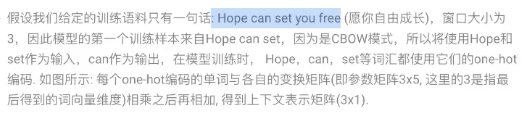

### Skip-Gram模式

给定一段用于训练的文本语料，再选定某段长度（窗口）作为研究对象，使用目标词汇预测上下文词汇

<img src="./markdown-note/images/img_3.png" width="600" height="400" />

假设我们给定的训练语料只有一句话：Hope can set you free（愿你自由成长)，窗口大小为3，因此模型的第一个训练样本来自Hope can set，因为是skipgram模式，所以将使用can 作为输入，Hope和set作为输出，在模型训练时，Hope，can，set等词汇都使用它们的 one-hot编码


如图所示：将can的one-hot编码与变换矩阵（即参数矩阵3x5,这里的3是指最后得到的词向量维度）相乘，得到目标词汇表示矩阵（3x1).接着，将目标词汇表示矩阵与多个变换矩阵（参数矩阵5x3）相乘，得到多个5x1的结果矩阵，它将与我们Hope和set对应的one-hot编码矩阵（5x1）进行损失的计算，然后更新网络参数完成一次模型迭代.

<img src="./markdown-note/images/img_4.png" width="600"  />

最后窗口按序向后移动，重新更新参数，直到所有语料被遍历完成，得到最终的变换矩阵即参数矩阵（3x5），这个变换矩阵与每个词汇的one-hot编码（5x1）相乘，得到的3x1的矩阵就是该词汇的word2vec张量表示 （实际上等价于 这个 3*5的对应序号的列就是这个词的word2vec张量表示）


下面看一个草图例子

<img src="./markdown-note/images/img_6.png" width="800"  />



## 实际案例

从 http:/mattmahoney.net/dc/enwik9.zip 下载维基百科语料信息，解压之后得到一个 1GB 的文件里面的内容包含了大量 html 标签

`perl data/wikifil.pl data/enwik9 > data/fil9 `

fasttext是facebook开源的一个词向量与文本分类工具

In [2]:
import fasttext
def dm_fasttext_train_save_load():
    # 使用train_unsupervised（无监督训练方法）训练词向量 （这里选择一部分做训练提升速度）
    # 查看方法实现就知道默认使用的是skipgram 模式，默认个词向量维度为 100
    #在训练词向量过程中，我们可以设定很多常用超参数来调节我们的模型效果，如：
    #无监督训练模式：‘skipgram’或者‘cbow'，默认为'skipgram' 【CBOW 是“根据上下文猜中间词”，适合快速入门和数据量小的情况；Skip-Gram 是“根据一个词猜上下文”，虽然慢一些但效果更好，适合追求质量的项目。】
    #词嵌入维度dim：默认为100，但随着语料库的增大，词嵌入的维度往往也要更大，
    #数据循环次数epoch：默认为5，但当你的数据集足够大，可能不需要那么多次.
    #学习率1r：默认为0.05，根据经验，建议选择[0.01，1]范围内.
    #使用的线程数thread：默认为12个线程，一般建议和你的cpu核数相同，
    mymodel = fasttext.train_unsupervised("./data/wiki/fil9_sentences_part_aa")
    # mymodel=fasttext.train_unsupervised("./data/wiki/fil9_sentences_part_aa",model='skipgram',dim=100,epoch=5,lr=0.05,thread=12)

    # 保存已经训练好的词向量
    mymodel.save_model("./data/fil9.bin")
    # 载入已经训练好的词向量
    # fasttext.load_model("./data/fil9.bin")

dm_fasttext_train_save_load()

Read 7M words
Number of words:  92208
Number of labels: 0
Progress: 100.0% words/sec/thread:  165110 lr:  0.000000 avg.loss:  1.744048 ETA:   0h 0m 0s


In [3]:
model=fasttext.load_model("./data/fil9.bin")
vector = model.get_word_vector("the")
print('myvector =',type(vector),vector.shape,vector)

myvector = <class 'numpy.ndarray'> (100,) [-3.12386416e-02 -2.69759089e-01 -2.41703466e-01  2.89024025e-01
  1.10343225e-01  1.73226804e-01 -1.08362339e-01  1.59536451e-01
 -3.90933268e-03  5.51193118e-01 -1.20404147e-01 -6.34024322e-01
 -5.66116422e-02  4.09676135e-02  3.53513867e-01  2.83305738e-02
  3.83665711e-01  5.43652892e-01  2.78686434e-01 -1.57819450e-01
 -4.13299680e-01 -2.35754400e-01 -1.12659141e-01  3.25731933e-02
  7.20700026e-01  2.92525709e-01 -1.25119314e-01 -2.43881747e-01
 -3.45185772e-02 -2.96425939e-01  5.24710529e-02  4.69069835e-03
  7.76486397e-02  4.35964495e-01 -3.67139503e-02  1.95199263e-03
  2.49197669e-02 -7.17261016e-01 -1.23907268e-01 -2.81845301e-01
 -1.69877812e-01 -1.79335307e-02 -1.48514614e-01 -1.74198255e-01
  1.46797508e-01  2.71599561e-01  3.50922883e-01  6.59388006e-01
  2.92527173e-02 -1.19670480e-01  4.40981746e-01  1.64113119e-01
 -2.24764138e-01  7.72603303e-02 -1.34225428e-01  4.33445454e-01
 -3.52241457e-01  8.07019472e-02 -4.44162667e-01

In [6]:
# 查看 dog 相关的词汇 也就是邻近单词 【可以发现 词向量之后 相同含义的词 他们的词向量的距离也很接近】
model.get_nearest_neighbors('dog')

[(0.8019997477531433, 'dog,'),
 (0.7973442673683167, 'dogs'),
 (0.773752748966217, 'dog.'),
 (0.6673745512962341, 'cat'),
 (0.6568814516067505, 'dog]]'),
 (0.6438451409339905, 'dogs,'),
 (0.6319398880004883, 'dogsled'),
 (0.6317462921142578, 'dog-like'),
 (0.6294801235198975, 'cow'),
 (0.6221980452537537, 'cows')]

## word embedding

word2vec 存在两个问题，第一个问题就是需要先对语料进行词向量化之后才能进行后续的模型训练（也就是完成我们的目标变成了两个比较割裂的步骤 一个是词向量处理一个是模型训练），这就导致无法处理一词多义的场景，此外，比如我现在的词向量是依据三国演义小说来训练得到的，然后我拿这个词向量模型来做好评还是差评的预测就不合适。

对于这两个问题embedding 就能做很好的规避，因为 embedding 是作为整体网络的单独的一层，而不是单独的一个神经网络来处理的


In [8]:
## 自己写一个tokenizer 避免 tensorFlow 框架的导包问题
class Tokenizer:
    def __init__(self):
        # 存储词到ID的映射 {word: id}
        self.word_index = {}
        # 存储ID到词的映射 {id: word} —— 反向索引
        self.index_word = {}
        # 下一个要分配的ID（从1开始，0通常保留给填充或特殊符号）
        self.next_id = 1

    def fit_on_texts(self, texts):
        """
        遍历所有文本，为每个新出现的词分配一个唯一ID
        :param texts: 列表，元素可以是字符串或已经分好词的列表
        """
        for text in texts:
            # 如果输入的是字符串，我们假设它已经被分词了；如果是列表，直接处理
            words = text if isinstance(text, list) else [text]

            for word in words:
                if word not in self.word_index:
                    self.word_index[word] = self.next_id
                    self.index_word[self.next_id] = word
                    self.next_id += 1

    def texts_to_sequences(self, texts):
        """
        将文本列表转换为对应的ID序列列表
        :param texts: 列表，元素是已分词的列表或单个词
        :return: 二维列表 [[id1, id2, ...], [id3, id4, ...]]
        """
        sequences = []
        for text in texts:
            # 确保是列表形式
            words = text if isinstance(text, list) else [text]
            seq = [self.word_index.get(word, 0) for word in words]  # 未知词用0代替
            sequences.append(seq)
        return sequences

    @property
    def num_words(self):
        """返回词汇表大小"""
        return len(self.word_index)


In [17]:
import jieba
import torch
import torch.nn as nn
def demo2_embedding():
    # ==========================================
    # # 1. 对句子进行分词 (Chinese Word Segmentation)
    # 计算机看不懂中文，需要先把长句切分成一个个独立的词语
    sentence1 = '传智教育是一家上市公司，旗下有黑马程序员品牌，我是在黑马这里学习人工智能'
    sentence2 = '我要做自然语言处理'
    sentences = [sentence1, sentence2]

    word_list = []
    for s in sentences:
        # 使用 jieba 库进行分词，lcut 表示返回的是列表形式
        word_list.append(list(jieba.cut(s)))

   # 二维矩阵 输出示例：[['传智', '教育', '是', ...], ['我', '要', '做', ...]]
    print('word_list-->', word_list)

    # ==========================================
    # # 2. 对句子/words求ID映射 (Tokenization & Indexing)
    mytokenizer = Tokenizer()
    mytokenizer.fit_on_texts(word_list)

    # ==========================================
    # # 3. 打印 my_token_list (Token List)
    # 获取 Tokenizer 内部生成的完整词表和对应的反向索引
    my_token_list = mytokenizer.index_word.values()
    print("my_token_list->", my_token_list,'total_words->',mytokenizer.num_words)


    # ==========================================
    # # 4. 打印文本被数值化以后的结果 (Integer Sequencing)
    sentence2id = mytokenizer.texts_to_sequences(word_list)
    # 输出  [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 6, 12, 3, 13, 9, 14, 15, 16], [17, 18, 19, 20]]
    # print("-->sentence2id-->", sentence2id)



    # ==========================================
    # # 5. 创建 nn.Embedding (The Embedding Layer) 也就是创建 embedding 层
    # num_embeddings: 词典的大小（词汇量）也就是总共有多少个词，可以比总词数大但是不能小
    # embedding_dim: 向量的维度，也就是这个词语的特征向量有多长
    emb = nn.Embedding(num_embeddings=len(my_token_list), embedding_dim=8)
    # 打印权重的具体数据，查看这个“查找表”里存的向量到底是什么样子
    # shape=torch.Size([20, 8])
    # 答应当前 embedding 层的网络权重参数
    # print('embedding层向量矩阵-->', emb.weight.data, emb.weight.data.shape)


    for idx in range(mytokenizer.num_words):
        word = mytokenizer.index_word[idx+1]
        vec=emb(torch.tensor(idx))
        print(f"“{word}”的词向量:", vec)



demo2_embedding()

word_list--> [['传智', '教育', '是', '一家', '上市公司', '，', '旗下', '有', '黑马', '程序员', '品牌', '，', '我', '是', '在', '黑马', '这里', '学习', '人工智能'], ['我要', '做', '自然语言', '处理']]
my_token_list-> dict_values(['传智', '教育', '是', '一家', '上市公司', '，', '旗下', '有', '黑马', '程序员', '品牌', '我', '在', '这里', '学习', '人工智能', '我要', '做', '自然语言', '处理']) total_words-> 20
“传智”的词向量: tensor([ 0.3824,  0.3775,  1.4538, -0.8389, -1.5875, -1.3780, -0.1003, -0.5367],
       grad_fn=<EmbeddingBackward0>)
“教育”的词向量: tensor([-0.5503, -1.0675, -0.2620, -0.1210, -1.2500, -0.5760, -0.9100, -0.8287],
       grad_fn=<EmbeddingBackward0>)
“是”的词向量: tensor([0.2640, 0.6005, 0.4266, 1.0707, 0.4731, 0.8679, 0.8195, 0.0623],
       grad_fn=<EmbeddingBackward0>)
“一家”的词向量: tensor([ 0.3347,  0.0335,  0.7260, -0.1907,  1.2789, -0.4238,  1.1635,  1.2965],
       grad_fn=<EmbeddingBackward0>)
“上市公司”的词向量: tensor([-0.4957,  2.1870, -0.5309,  0.3120,  0.8934,  1.7848, -1.0768, -2.0331],
       grad_fn=<EmbeddingBackward0>)
“，”的词向量: tensor([0.8371, 0.4931, 0.4261, 1.6

核心疑问：“Embedding 层明明是个 Module，为什么没有 forward？也没有训练循环、反向传播、梯度下降？它怎么‘学习’词向量？”

这个问题我们要拆开来看：

- 首先对于 Embedding 类本身而言，它确实是继承了 Module 你去查看源码的时候你也会发现这个类的实现 存在 `forward `方法。
- 然后就是上面给出的代码其实还没开始训练，因为我们说过词嵌入一般只是作为整体神经网络的一层，只有整体网络都搞好了才开始训练过程, 如下图代码所示


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# ========================
# Step 2: 构造简单数据集（每个样本是一个句子ID序列，标签是0或1）
class SimpleTextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), \
               torch.tensor(self.labels[idx], dtype=torch.float32)

# ========================
# Step 3: 定义模型（继承 nn.Module）
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)           # [batch, seq_len, embed_dim]
        pooled = embedded.mean(dim=1)          # [batch, embed_dim] （简单平均池化）
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# ========================
# Step 4: 准备数据和模型
sentences = [
    ['我', '喜欢', '学习'],
    ['讨厌', '考试'],
    ['人工智能', '很', '有趣'],
    ['编程', '很难']
]
labels = [1, 0, 1, 0]  # 正负样本

tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)

vocab_size = len(tokenizer.word_index)
embed_dim = 8
hidden_dim = 16
output_dim = 1

dataset = SimpleTextDataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

model = TextClassifier(vocab_size, embed_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ========================
# Step 5: 开始训练！
print("开始训练...")
for epoch in range(100):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")




# 文本数据分析

文本数据分桥的作用：文本数据分析能够有效帮助我们理解数据语料，快速检查出语料可能存在的问题，并指导之后模型训练过程中一些超参数的选择，

常用的几种文本数据分析方法：
- 标签数量分布
- 句子长度分布
- 词频统计与关键词词云

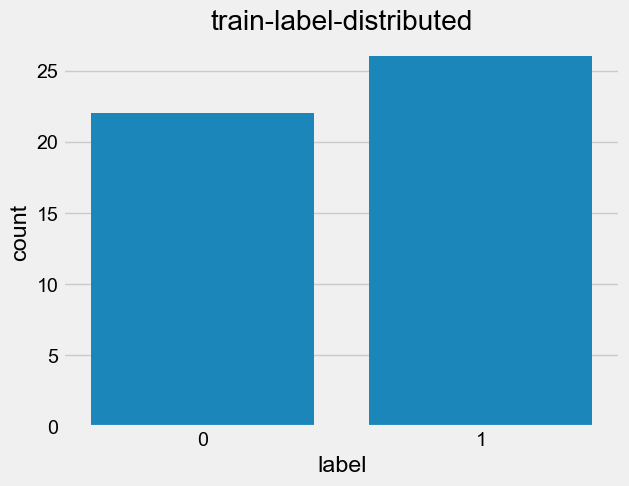

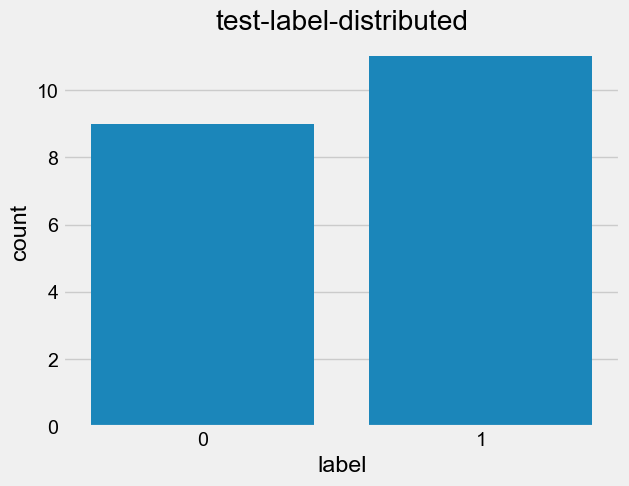

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
'''
获取标签数量分布
在深度学习模型评估中：我们一般使用ACC作为评估指标, 简单来说我们希望正例样本和反例样本的数量大致相当，如果差距过大就需要做删减或者补充
'''


# macOS 使用系统自带的中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

train_data = pd.read_csv('data/comment_train.tsv',sep='\t')

# 统计 0 和 1 的标签分组数量
sns.countplot(x='label', data=train_data)
plt.title('train-label-distributed')
plt.show()

test_data = pd.read_csv('data/comment_test.tsv',sep='\t')
sns.countplot(x='label', data=test_data)
plt.title('test-label-distributed')
plt.show()

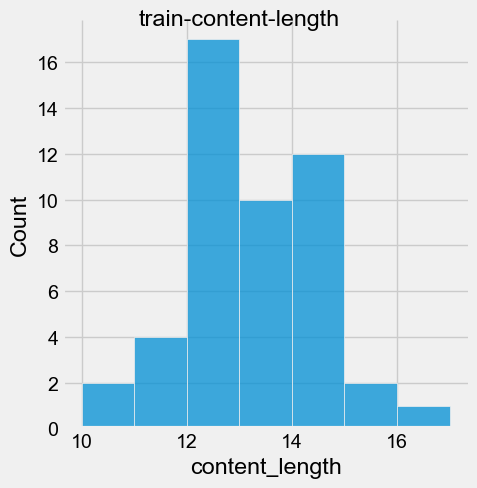

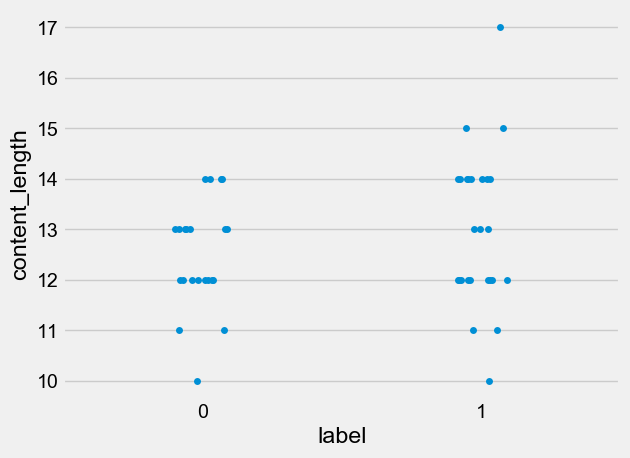

In [23]:
'''
获取训练集的句子长度分布
通过绘制句子长度分布图，可以得知我们的语料中大部分句子长度的分布范围，因为模型的输入要求为固定尺寸的张量，合理的长度范围对之后进行句子截断补齐（规范长度）起到关键的指导作用.
'''
train_data['content_length'] = train_data['content'].apply(lambda x: len(x))
# 也可以像下面这样使用 map 函数，但是这样不是很推荐 不太直观 推荐使用 pandas 的 apply 函数
# train_data['content_length'] = list(map(lambda x:len(x), train_data['content']))

g = sns.displot(x='content_length', data=train_data)
g.figure.suptitle('train-content-length')  # 设置标题
plt.show()


sns.stripplot(x='label', y='content_length', data=train_data)
plt.show()


通过绘制句子长度分布图可以得知我们的语料中大部分句子长度的分布范围，因为模型的输入要求为固定尺寸的张量，**合理的长度范围对之后进行句子截断补齐（规范长度）起到关键的指导作用**

In [27]:
'''
获取训练集和验证集的词总数
'''
import jieba
from itertools import chain

# 这里返回的是一个迭代器对象 <class 'map'>
t1 = map(lambda x:list(jieba.cut(x)), train_data['content'])
# * 的作用：将可迭代对象拆解成独立的参数
# *t1 将迭代器拆解成：chain(['房', '间'], ['服', '务'], ['非', '常'])
# chain 将这些列表连接成一个迭代器：['房', '间', '服', '务', '非', '常']
t2 = chain(*t1)
t3 = set(t2)
print(f'训练集的词汇总数为 {len(t3)}')

t4 = set(chain(*map(lambda x:list(jieba.cut(x)), test_data['content'])))
print(f'验证集的词汇总数为 {len(t4)}')

训练集的词汇总数为 198
验证集的词汇总数为 111


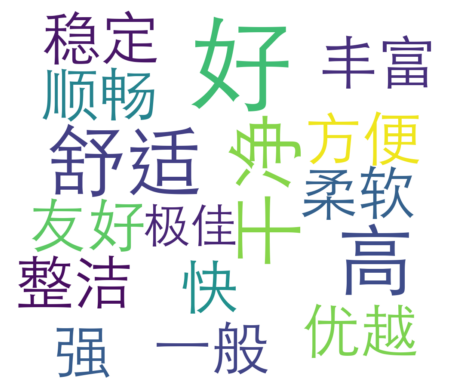

In [4]:
'''
形容词词云统计
'''
from wordcloud import WordCloud
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import pandas as pd
from itertools import chain

def get_adj_list(text):
    return [w.word for w in pseg.cut(text) if w.flag == 'a']

def get_word_cloud(key_word_list):
    # 创建词云对象
    # font_path: 使用 macOS 系统自带的中文字体（避免依赖外部字体文件）
    # max_words: 最多显示100个词
    # background_color: 背景色为白色
    # width/height: 词云图片尺寸
    # margin: 词之间的间距
    wordcloud = WordCloud(
        font_path='/System/Library/Fonts/STHeiti Light.ttc',
        max_words=100,
        background_color='white',
        width=1000,
        height=860,
        margin=1
    )
    keyword=" ".join(key_word_list)
    wordcloud.generate(keyword)
    #wordcloud.to_file("data/wordcloud.png")
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

def draw_word_cloud_positive():
    train_data = pd.read_csv('data/comment_train.tsv',sep='\t')
    positive=train_data[train_data['label']==1]['content']
    positive_adj=list(chain(*map(lambda x:get_adj_list(x), positive)))
    get_word_cloud(positive_adj)

draw_word_cloud_positive()

# 文本特征处理
文本特征处理的作用：文本特征处理包括为语料添加具有普适性的文本特征，如：n-gram特征，以及对加入特征之后的文本语料进行必要的处理，如：长度规范.这些特征处理工作能够有效的将重要的文本特征加入模型训练中，增强模型评适指标.

## n-gram特征

给定一段文本序列，其中n个词或字的相邻共现特征即n-gram特征，常用的n-gram特征是bi-gram和tri-gram特征，分别对应n为2和3

举个例子：

```text
假设给定分词列表：["是谁”，“敲动”，“我心"] 对应的数值映射列表为：[1，34，21]
我们可以认为数值映射列表中的每个数字是词汇特征。
除此之外，我们还可以把“是谁”和“敲动”两个词共同出现且相邻也作为一种特征加入到序列列表中，
假设1000就代表”是谁“和“敲动”共同出现且相邻
此时数值映射列表就变成了包含2-gram特征的特征列表：[1，34，21，1000]
这里的”是谁"和"敲动”共同出现且相邻就是bi-gram特征中的一个，
“敲动"和”我心"也是共现且相邻的两个词汇，因此它们也是bi-gram特征。
假设1001代表“敲动”和“我心"共同出现且相邻
那么最后原始的数值映射列表 [1，34，21] 添加了 bi-gram 特征之后就变成了 [1，34，21，1000，1001]
```


其实我的理解就是给每个句子增加一些新的特征，就类似之前机器学习线性回归的时候当时一条直线拟合不好的时候我们会添加多项式特征让它学习更多特征来拟合的更好，这里其实是一样的目的

In [5]:
def create_ngram_features(input_list, ngram_range=2):
    """
    description: 从数值列表中提取所有的 n-gram特征
    input_list: 数值列表
    ngram_range: n-gram 范围
    output: n-gram 特征
    """
    return set(zip(*[input_list[i:] for i in range(ngram_range)]))


create_ngram_features([1, 34, 21], ngram_range=2)


{(1, 34), (34, 21)}

上面的代码比较抽象的代码是这段：`set(zip(*[input_list[i:] for i in range(ngram_range)]))`

下面对这段代码进行下解释

当 i = 0 时，input_list[i:] = input_list[0:] = input_list = [1,34,21]

当 i = 1 时，input_list[i:] = input_list[1:] =[34,21]

经过列表推导式处理后得到 [[1,34,21], [34,21]] 再经过 * 拆包之后 得到 [1,34,21], [34,21]

对上面的两个数组做zip操作（zip 操作在需要合并的数组长度不一致的时候会以最短的为准），结果为：[(1, 34), (34, 21)] 再经过 set 处理就得到了 {(1, 34), (34, 21)}



In [6]:
create_ngram_features([1, 2, 3, 4, 5], ngram_range=2)

{(1, 2), (2, 3), (3, 4), (4, 5)}

ngram 在最开始是为了解决基于语料库的全部数据来估算一个句子出现的概率应该怎么算的问题：

假设我们拥有一个仅包含以下两句话的迷你语料库：`datawhale agent learns`, `datawhale agent works`。我们的目标是：使用 Bigram (N=2) 模型，估算句子 datawhale agent learns 出现的概率。根据 Bigram 的假设，我们每次会考察连续的两个词（即一个词对）。

_P(datawhale agent learns) = P(datawhale) * P(agent | datawhale) * P(learns | agent)_


先算 P(datawhale) = 2/6


再算 P(agent | datawhale) 根据条件概率公式 可以得到 `P(agent | datawhale)  =  P( datawhale agent ) / P(datawhale)`

假定 count(datawhale agent) 代表  datawhale 和 agent 同时出现的个数 那么

`P(agent datawhale) = count(datawhale agent)/ all_count`

`P(datawhale) =  count(datawhale)/ all_count`

所以可以推导出来 `P(agent | datawhale) = P( agent datawhale ) / P(datawhale) = count(datawhale agent) / count(datawhale) = 2/2 = 1`

同理 `P(learns | agent) =  count(agent learns) / count(agent)  = 1/2`


那么  `P(datawhale agent learns) = P(datawhale) * P(agent | datawhale) * P(learns | agent) = 2/6 * 2/2 * 1/2 = 1/6`

## 文本长度规范
一般模型的输入需要等尺寸大小的矩阵，因此在进入模型前需要对每条文本数值映射后的长度进行规范，此时将根据句子长度分布分析出覆盖绝大多数文本的合理长度，对超长文本进行截断，对不足文本进行补齐（一般使用数字0），这个过程就是文本长度规范

In [11]:
def padding_sentences(sentences, max_len):
    res = []
    for sentence in sentences:
        if len(sentence) > max_len:
            sentence = sentence[:max_len]
        else:
            sentence += [0] * (max_len - len(sentence))
        res.append(sentence)
    return res

# 假定现在存在两条文本一个长度大于 10 一个长度小于 10
x_train =[[1,23,5,32,55,63,2,21,78,32,23,1],[2,32,1,23,1]]
res = padding_sentences(x_train,10)
print(res)

[[1, 23, 5, 32, 55, 63, 2, 21, 78, 32], [2, 32, 1, 23, 1, 0, 0, 0, 0, 0]]


## 回译数据增强
回译数据增强目前是文本数据增强方面效果较好的增强方法，一般基于google、有道等翻译接口，将文本数据翻译成另外一种语言（一般选择小语种).
之后再翻译回原语言，即可认为得到与原语料同标签的新语料，新语料加入到原数据集中即可认为是对原数据集数据增强

回译数据增强优势：
- 操作简便，获得新语料质量高，

回译数据增强存在的问题：
- 在短文本回译过程中，新语料与原语料可能存在很高的重复率，并不能有效增大样本的特征空间

这里有个重点要明白，**这种思路其实和把一句话换成多种表述但是意思不变的思路是一致的**，比如"你今天挺好看的"，我们经过这种回译之后得到的新句子可能就是 “你今天真的很迷人” 也就是说最好是和原来的句子意思一致但是表述不同
这就存在一个问题就是如果文本很短，这就导致回译最后的效果不好，无法对原始语料做很好的扩容

高重复率解决办法：
- 进行连续的多语言翻译，如：中文→韩文→日语→英文→中文，根据经验，最多只采用3次连续翻译，更多的翻译次数将产生效率低下，语义失真等问题


